In [1]:
import sys
sys.path.append('../src/training-on-CM2.6')
sys.path.append('../src/tensor_calculus')
import xarray as xr
import xgcm

import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=".*Dataset.dims.*"
)

from helpers.plot_helpers import *
from helpers.selectors import *
from tensor_calculus import Tensor

%load_ext autoreload
%autoreload 3

# Sequential regression

In [ ]:
ds = xr.open_mfdataset('/scratch/pp2681/mom6/equation-discovery/Pacific_mean_medium/*.nc').load()

In [7]:
set_of_features=list(np.arange(0,237))

In [8]:
set_of_features_filtered = [0]
Pacific = lambda x: x.sel(xh=slice(-215,-150), yh=slice(30,40))

In [9]:
for feature in range(0,237):
    corrs = np.nan_to_num(np.array([float(np.abs(xr.corr(Pacific(ds[f'{feature}_SGS_mean']), Pacific(ds[f'{feature2}_SGS_mean'])))) for feature2 in set_of_features_filtered]), 0.)

    if corrs.max() < 0.9:
        set_of_features_filtered.append(feature)
        print(f'Feature {feature} with max corr {corrs.max()} added to the filtered set')

Feature 1 with max corr 0.2848347738757354 added to the filtered set
Feature 2 with max corr 0.031038550720535907 added to the filtered set
Feature 3 with max corr 0.5971109023789642 added to the filtered set
Feature 4 with max corr 0.5408619925868032 added to the filtered set
Feature 5 with max corr 0.13284273191334164 added to the filtered set
Feature 6 with max corr 0.0998030034249278 added to the filtered set
Feature 7 with max corr 0.6568352814879489 added to the filtered set
Feature 8 with max corr 0.6682759024740608 added to the filtered set
Feature 9 with max corr 0.6459667564886556 added to the filtered set
Feature 10 with max corr 0.7695819649036452 added to the filtered set
Feature 11 with max corr 0.3633448345511522 added to the filtered set
Feature 12 with max corr 0.7162107587708676 added to the filtered set
Feature 13 with max corr 0.820338690871925 added to the filtered set
Feature 14 with max corr 0.7133706617129865 added to the filtered set
Feature 16 with max corr 0.

In [24]:
# with open('set_of_features_filtered.npy', 'wb') as f:
#     np.save(f, set_of_features_filtered)

In [48]:
ds[f'{19}_SGS_mean'].long_name

'$(\\partial_Ju_I^{\\perp})(\\partial_I\\partial_iu_J)$'

In [49]:
ds[f'{21}_SGS_mean'].long_name

'$(\\partial_Ju_I)(\\partial_I\\partial_Ju_i)$'

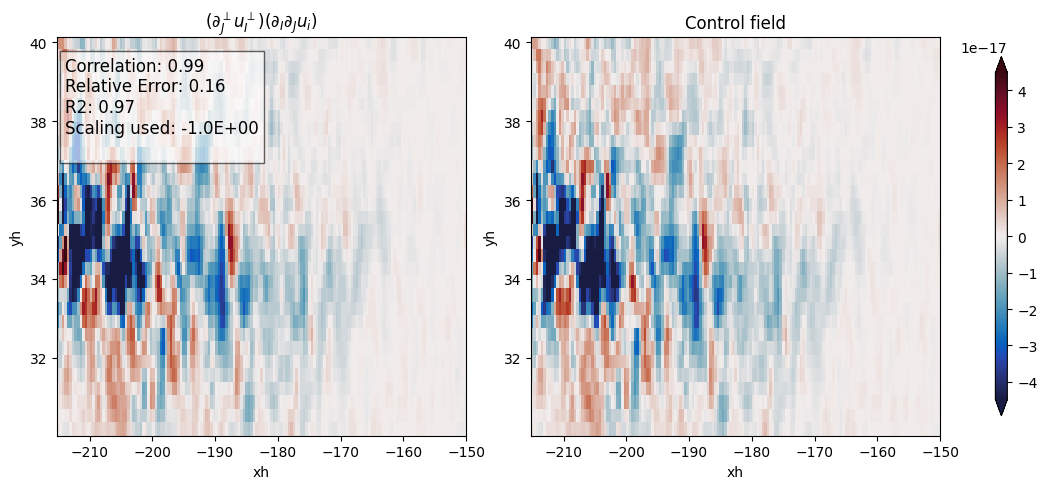

In [57]:
j = 24
compare(ds[f'{j}_SGS_mean'].isel(i=0), ds['21_SGS_mean'].isel(i=0), selector=Pacific, scale=True,
label_test=ds[f'{j}_SGS_mean'].long_name);

In [58]:
def corr(x,y):
    '''
    Not centered correlation as we do not have intercept
    in our linear model
    '''
    return float((x*y).mean() / np.sqrt((x**2).mean() * (y**2).mean()))

In [72]:
from sklearn.linear_model import LinearRegression
import sklearn
from sklearn.preprocessing import StandardScaler
from IPython.display import Math, display

def sequential_regression(dataset,
    set_of_features=None, 
    metric_key = 'transfer',
    num_iterations = 1,
    show_top=1,
    max_derivative = 1,
    ):

    target = dataset[metric_key]
    target_test = dataset[metric_key]
    selected_features = []
    residual = target.copy()
    for iteration in range(num_iterations):
        # Compute correlation with residuals
        corrs = []
        for key in set_of_features:
            feature = dataset[f'{key}_{metric_key}'].copy()
            feature_test = dataset[f'{key}_{metric_key}'].copy()
            corrs.append((key, feature, feature_test, np.abs(corr(feature, residual))))
        
        # Print top 5 correlations
        corrs.sort(key = lambda x: x[3], reverse=True)
        for i in range(min(show_top, len(corrs))):
            key, feature, feature_test, correlation = corrs[i]
            display(Math(dataset[f'{key}_SGS_mean'].long_name+f' correlation of tensor {key} with residual: ${correlation:.2f}$'))

        if (len(corrs) == 0):
            return
        # Select best feature
        idx = input('Which tensor to choose?')
        print(f'{idx}th feature from the top is chosen')
        selected_features.append((corrs[int(idx)][:3]))

        # Regression for a set of current features
        y = target.values.reshape(-1,1)
        y_test = target_test.values.reshape(-1,1)
        x = np.array([xx[1].values.reshape(-1) for xx in selected_features]).T
        x_test = np.array([xx[2].values.reshape(-1) for xx in selected_features]).T

        # Scaling features
        scaler_x = StandardScaler(with_mean=False)
        scaler_y = StandardScaler(with_mean=False)
        x_scaled = scaler_x.fit_transform(x)
        y_scaled = scaler_y.fit_transform(y)

        model = LinearRegression(fit_intercept=False)
        model.fit(x_scaled,y_scaled)

        y_pred = scaler_y.scale_ * model.predict(x_scaled)
        r2 = sklearn.metrics.r2_score(y, y_pred)

        x_test_scaled = scaler_x.transform(x_test)
        y_test_pred = scaler_y.scale_ * model.predict(x_test_scaled)
        r2_test = sklearn.metrics.r2_score(y_test, y_test_pred)
        
        print(f"Interation {iteration}: R squared [train/test]: [{r2:.4f},{r2_test:.4f}]")

        # Remove already used feature
        set_of_features.remove(corrs[0][0])
        # Update residual
        residual = target.copy() - y_pred.reshape(target.shape)

        print()

    print('Final expression:')
    display(Math((*[dataset[f'{key[0]}_SGS_mean'].long_name for key in selected_features])))
        

SyntaxError: cannot use starred expression here (1303025503.py, line 71)

In [73]:
import copy
sequential_regression(Pacific(ds), set_of_features=copy.deepcopy(set_of_features_filtered),
                      num_iterations=2,  show_top=5,
                      metric_key = 'dEdt')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

0th feature from the top is chosen
Interation 1: R squared [train/test]: [0.8944,0.8944]

Final expression:


ValueError: unknown url type: '$((\\partial_Iu_I^{\\perp})(\\partial_K^{\\perp}\\partial_Iu_K))(\\partial_Iu_i)$'

array([<Axes: title={'center': 'Tested field'}, xlabel='xh', ylabel='yh'>,
       <Axes: title={'center': 'Control field'}, xlabel='xh', ylabel='yh'>],
      dtype=object)

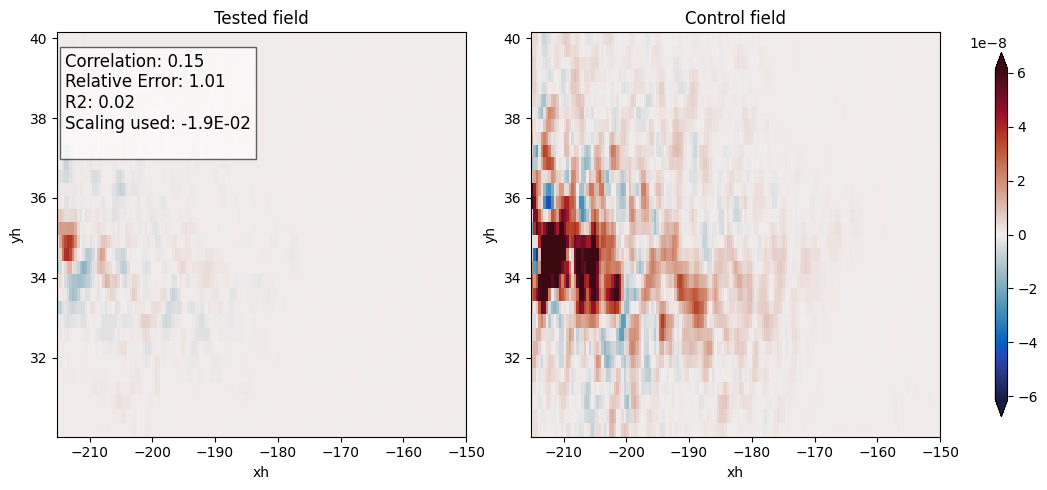

In [128]:
compare(ds['86_dEdt'].isel(i=0), ds['dEdt'].isel(i=0), selector=Pacific, scale=True)

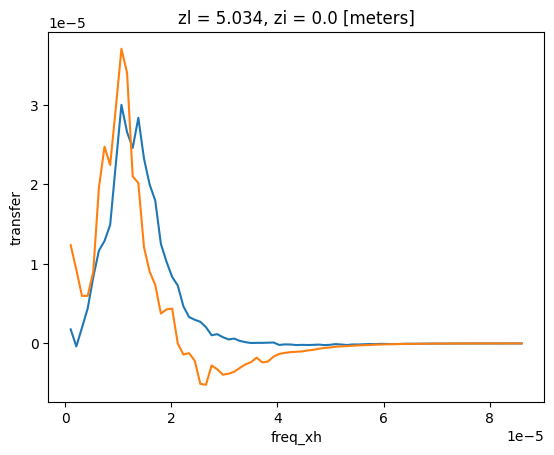

In [127]:
(-1e+5*ds['274_transfer']).isel(i=1).plot()
ds['transfer'].isel(i=1).plot()